# Exploratory Data Analysis of Dataset20

This notebook performs exploratory data analysis on Dataset20, which contains 17 environmental, socioeconomic, land-cover, and cellular-infrastructure predictors for 4,985 labelled 1 km × 1 km grid cells.

The analysis examines data completeness, class imbalance, feature distributions, correlations, combined predictor patterns, and the spatial distribution of LTE and 5G NR signal strength.

The findings inform the subsequent feature-engineering and machine-learning stages. All relationships are interpreted as exploratory associations rather than causal effects.

※ Related dissertation sections
 - Section 3.1 (Research Approach—Data Understanding)
 - Section 4.1.2 (Exploratory Data Analysis), and Table 4.1 (Summary of EDA Findings and Feature-Engineering Responses).

In [ ]:
# ============================================================
# EDA 1. Load and Validate Dataset20
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = (
    "/content/drive/MyDrive/Dissertation/Experiments/"
    "최종실험(수정)/Dataset_Build"
)

dataset20_path = os.path.join(
    base_dir,
    "08_Final_Datasets",
    "dataset20_final.csv"
)

dataset20 = pd.read_csv(
    dataset20_path,
    low_memory=False
)

print("Dataset20 shape:", dataset20.shape)
print("Unique grid IDs:", dataset20["grid_id"].nunique())
print("Duplicate grid IDs:", dataset20["grid_id"].duplicated().sum())

print("\nColumns:")
print(dataset20.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset20 shape: (4985, 28)
Unique grid IDs: 4985
Duplicate grid IDs: 0

Columns:
['grid_id', 'lte_min_rsrp', 'lte_mean_rsrp', 'lte_median_rsrp', 'lte_point_count', 'lte_signal_class', 'nr_min_rsrp', 'nr_mean_rsrp', 'nr_median_rsrp', 'nr_point_count', 'nr_signal_class', 'VV', 'VH', 'NDVI', 'NDBI', 'population', 'nightlight', 'tree_ratio', 'grass_ratio', 'crop_ratio', 'builtup_ratio', 'water_ratio', 'cell_count', 'operator_count', 'gsm_count', 'umts_count', 'lte_count', 'nr_count']


## 1. Dataset Validation and Feature Definition

Dataset20 is loaded and checked for duplicate grid identifiers and structural consistency.

The analysis uses 17 predictors covering radar backscatter, spectral indices, land cover, population, night-time light, and OpenCellID-derived cellular-infrastructure information.

※Related dissertation sections
 - Section 3.1 (Research Approach—Data Understanding)
 - Section 4.1.2 (Exploratory Data Analysis).

In [ ]:
# ============================================================
# EDA 2. Define Feature Columns
# ============================================================

feature_cols = [
    "VV", "VH",
    "NDVI", "NDBI",
    "tree_ratio",
    "grass_ratio",
    "crop_ratio",
    "builtup_ratio",
    "water_ratio",
    "population",
    "nightlight",
    "cell_count",
    "operator_count",
    "gsm_count",
    "umts_count",
    "lte_count",
    "nr_count"
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 17
['VV', 'VH', 'NDVI', 'NDBI', 'tree_ratio', 'grass_ratio', 'crop_ratio', 'builtup_ratio', 'water_ratio', 'population', 'nightlight', 'cell_count', 'operator_count', 'gsm_count', 'umts_count', 'lte_count', 'nr_count']


## 2. Data Completeness and Class Distribution

Missing values are examined across all predictors before further analysis.

The distributions of the Excellent, Good, and Poor signal-quality classes are then compared separately for LTE and 5G NR. This assessment identifies the degree of target-class imbalance, particularly the scarcity of Poor LTE observations.

※Related dissertation sections
 - Section 2.8 (Class Imbalance and Poor-Signal Detection)
 - Section 4.1.2 (Exploratory Data Analysis)
 - Figure 4.1 (Distribution of LTE and 5G Signal-Quality Classes).

In [ ]:
# ============================================================
# EDA 3. Missing Values
# ============================================================

missing_table = pd.DataFrame({
    "missing_count": dataset20[feature_cols].isna().sum(),
    "missing_percent": dataset20[feature_cols].isna().mean() * 100
})

display(missing_table)

,missing_count,missing_percent
VV,0,0.0
VH,0,0.0
NDVI,0,0.0
NDBI,0,0.0
tree_ratio,0,0.0
grass_ratio,0,0.0
crop_ratio,0,0.0
builtup_ratio,0,0.0
water_ratio,0,0.0
population,0,0.0


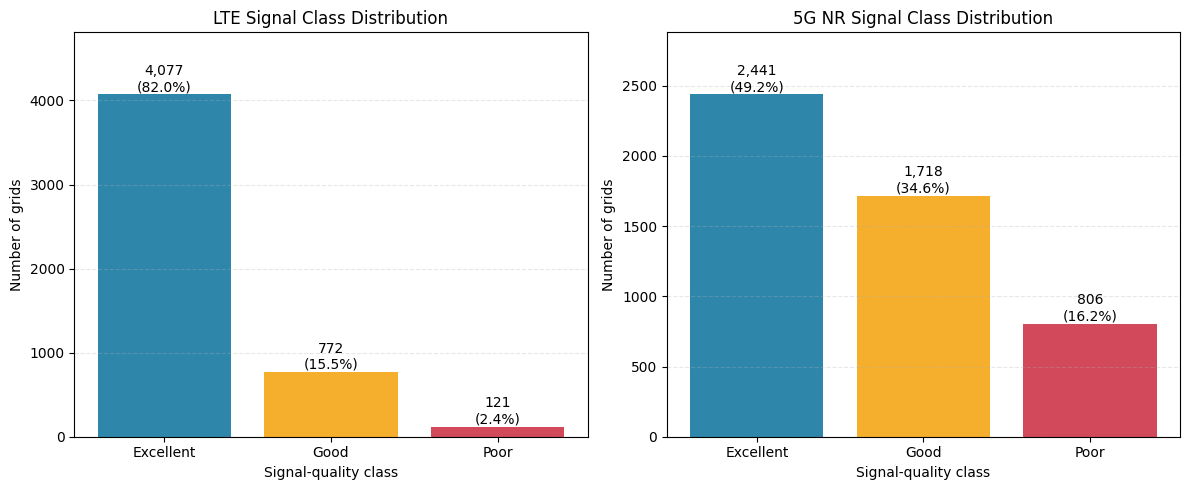


LTE Signal Class Distribution


,grid_count,percentage
lte_signal_class,,
Excellent,4077,82.03
Good,772,15.53
Poor,121,2.43



5G NR Signal Class Distribution


,grid_count,percentage
nr_signal_class,,
Excellent,2441,49.16
Good,1718,34.60
Poor,806,16.23


In [ ]:
# ============================================================
# EDA 4. Signal Class Distribution
# ============================================================

class_order = ["Excellent", "Good", "Poor"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

targets = [
    ("lte_signal_class", "LTE Signal Class Distribution"),
    ("nr_signal_class", "5G NR Signal Class Distribution")
]

for ax, (column, title) in zip(axes, targets):

    counts = (
        dataset20[column]
        .value_counts()
        .reindex(class_order, fill_value=0)
    )

    percentages = counts / counts.sum() * 100

    bars = ax.bar(
        class_order,
        counts.values,
        color=["#2E86AB", "#F6AE2D", "#D1495B"]
    )

    # Add count and percentage above each bar
    for bar, count, percentage in zip(
        bars,
        counts.values,
        percentages.values
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel("Signal-quality class")
    ax.set_ylabel("Number of grids")
    ax.set_ylim(0, counts.max() * 1.18)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Print numerical distributions
for column, title in targets:
    distribution = pd.DataFrame({
        "grid_count": dataset20[column]
            .value_counts()
            .reindex(class_order, fill_value=0),
        "percentage": dataset20[column]
            .value_counts(normalize=True)
            .reindex(class_order, fill_value=0)
            .mul(100)
            .round(2)
    })

    print(f"\n{title}")
    display(distribution)

## 3. Predictor Distributions and Class-Level Patterns

The distributions of selected predictors are visualised, with logarithmic transformations applied to highly skewed count variables.

Mean predictor values are subsequently compared across the Excellent, Good, and Poor classes for LTE and 5G NR.

※Related dissertation sections
 - Section 4.1.2 (Exploratory Data Analysis)
 - Table 4.1 (Summary of EDA Findings and Feature-Engineering Responses).

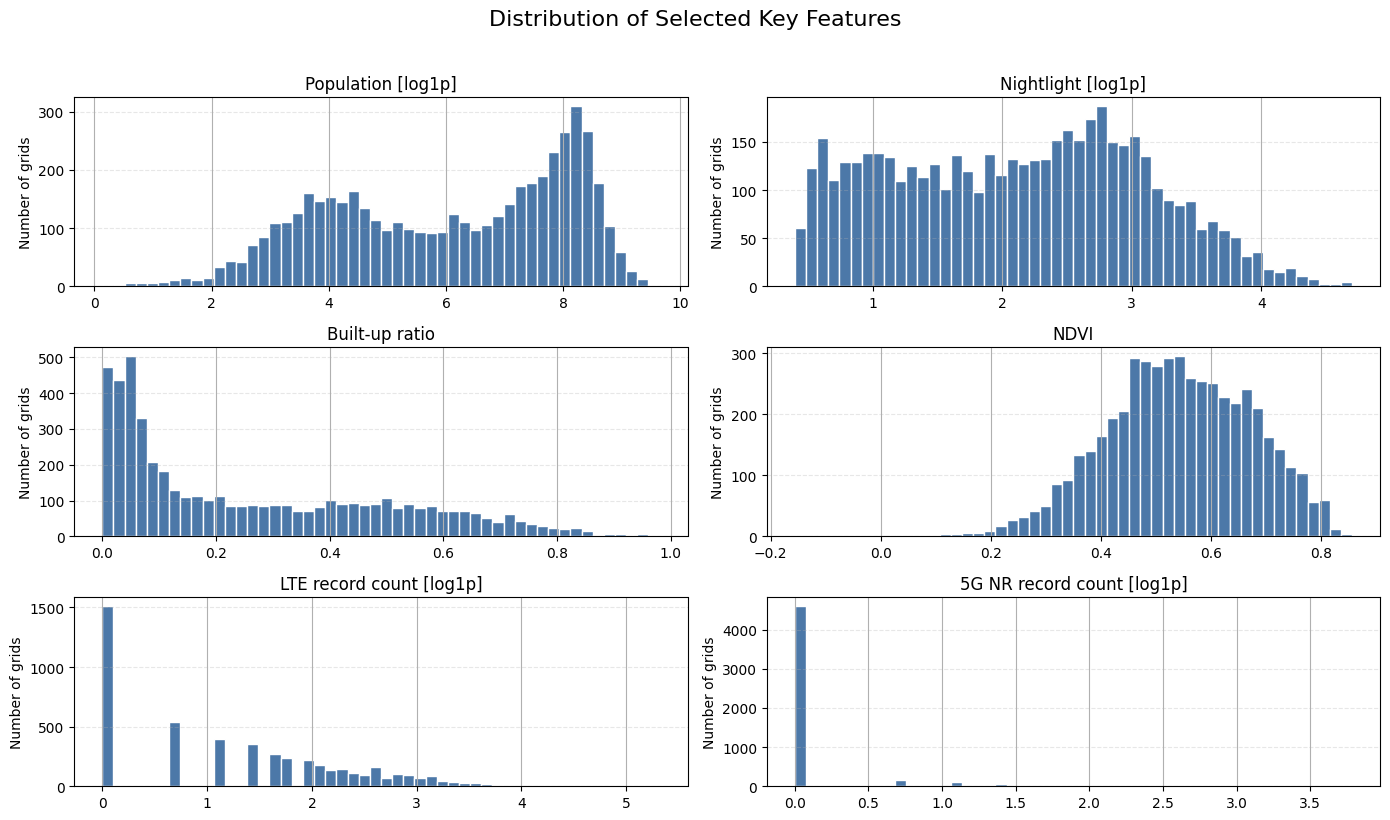

In [ ]:
# ============================================================
# EDA 5. Distribution of Selected Key Features
# ============================================================

plot_data = pd.DataFrame({
    "Population [log1p]": np.log1p(dataset20["population"]),
    "Nightlight [log1p]": np.log1p(dataset20["nightlight"]),
    "Built-up ratio": dataset20["builtup_ratio"],
    "NDVI": dataset20["NDVI"],
    "LTE record count [log1p]": np.log1p(dataset20["lte_count"]),
    "5G NR record count [log1p]": np.log1p(dataset20["nr_count"])
})

axes = plot_data.hist(
    figsize=(14, 8),
    bins=50,
    color="#4C78A8",
    edgecolor="white"
)

for ax in axes.flatten():
    ax.set_ylabel("Number of grids")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Distribution of Selected Key Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# EDA 6. Create LTE / NR Labelled Data
# ============================================================

lte_data = dataset20.dropna(
    subset=["lte_signal_class"]
).copy()

nr_data = dataset20.dropna(
    subset=["nr_signal_class"]
).copy()

print("LTE labelled grids:", lte_data.shape)
print("NR labelled grids :", nr_data.shape)

LTE labelled grids: (4970, 28)
NR labelled grids : (4965, 28)


In [ ]:
# ============================================================
# EDA 7. Mean Feature Values by Signal Class
# ============================================================

lte_means = (
    lte_data
    .groupby("lte_signal_class")[feature_cols]
    .mean()
    .loc[["Excellent", "Good", "Poor"]]
)

nr_means = (
    nr_data
    .groupby("nr_signal_class")[feature_cols]
    .mean()
    .loc[["Excellent", "Good", "Poor"]]
)

print("LTE Mean Feature Values")
display(lte_means.T)

print("\nNR Mean Feature Values")
display(nr_means.T)

LTE Mean Feature Values


lte_signal_class,Excellent,Good,Poor
VV,-9.375816,-10.424284,-11.025939
VH,-16.532918,-17.495677,-17.929019
NDVI,0.530976,0.579537,0.625721
NDBI,-0.114462,-0.134085,-0.161709
tree_ratio,0.273959,0.285630,0.275704
grass_ratio,0.276778,0.335954,0.440619
crop_ratio,0.147218,0.211791,0.200537
builtup_ratio,0.289274,0.150128,0.075495
water_ratio,0.010411,0.014401,0.006116
population,1781.568936,833.146900,295.293069



NR Mean Feature Values


nr_signal_class,Excellent,Good,Poor
VV,-8.834774,-9.974613,-10.953462
VH,-16.055468,-17.057538,-17.967774
NDVI,0.507479,0.559363,0.601233
NDBI,-0.105001,-0.126401,-0.143142
tree_ratio,0.277117,0.286691,0.249806
grass_ratio,0.239404,0.309073,0.399296
crop_ratio,0.121282,0.173013,0.238380
builtup_ratio,0.348697,0.216195,0.103971
water_ratio,0.010808,0.012909,0.007047
population,2183.494568,1320.661050,460.150844


## 4. Correlation Analysis

Pearson correlations are calculated between each predictor and median LTE and 5G NR RSRP.

A predictor-correlation matrix is also produced to identify relationships and potential redundancy among the environmental, socioeconomic, land-cover, and infrastructure variables.

These correlations are descriptive and do not establish causal relationships.

※Related dissertation sections
 - Section 4.1.2 (Exploratory Data Analysis)
 - Figure 4.2 (Pearson Correlations with Median RSRP)
 - Table 4.1 (Summary of EDA Findings and Feature-Engineering Responses).

,VV,VH,NDVI,NDBI,tree_ratio,grass_ratio,crop_ratio,builtup_ratio,water_ratio,population,nightlight,cell_count,operator_count,gsm_count,umts_count,lte_count,nr_count
LTE median RSRP,0.323,0.305,-0.251,0.166,-0.020,-0.212,-0.162,0.373,-0.009,0.31,0.334,0.172,0.190,0.043,0.034,0.191,0.057
5G NR median RSRP,0.393,0.354,-0.307,0.202,0.012,-0.287,-0.157,0.413,0.002,0.32,0.399,0.206,0.215,0.052,0.062,0.222,0.097


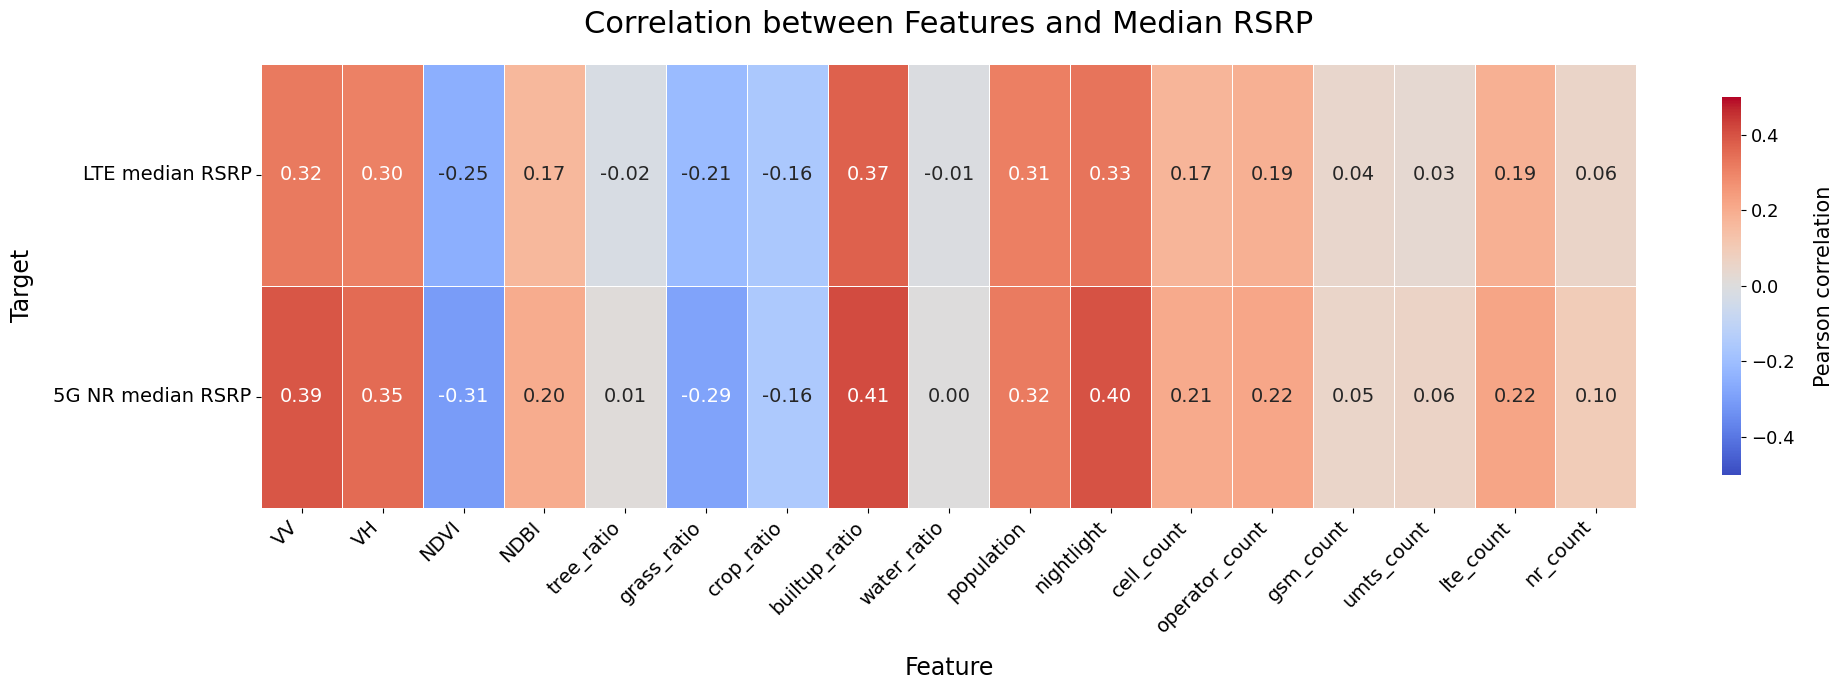

In [ ]:
# ============================================================
# EDA 8. Correlation between Features and Median RSRP
# ============================================================

# Calculate Pearson correlations
lte_correlations = lte_data[feature_cols].corrwith(
    lte_data["lte_median_rsrp"]
)

nr_correlations = nr_data[feature_cols].corrwith(
    nr_data["nr_median_rsrp"]
)

# Combine LTE and 5G NR correlations
correlation_heatmap = pd.DataFrame(
    [lte_correlations, nr_correlations],
    index=["LTE median RSRP", "5G NR median RSRP"]
)[feature_cols]

display(correlation_heatmap.round(3))

# Set a symmetric colour range
max_abs_corr = correlation_heatmap.abs().max().max()
colour_limit = np.ceil(max_abs_corr * 10) / 10

# Create enlarged heatmap
plt.figure(figsize=(20, 7))

ax = sns.heatmap(
    correlation_heatmap,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 14},
    cmap="coolwarm",
    center=0,
    vmin=-colour_limit,
    vmax=colour_limit,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Pearson correlation",
        "shrink": 0.85
    }
)

plt.title(
    "Correlation between Features and Median RSRP",
    fontsize=22,
    pad=22
)

plt.xlabel(
    "Feature",
    fontsize=17,
    labelpad=14
)

plt.ylabel(
    "Target",
    fontsize=17,
    labelpad=14
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=14
)

plt.yticks(
    rotation=0,
    fontsize=14
)

# Enlarge colour-bar text
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=13)
colorbar.set_label(
    "Pearson correlation",
    fontsize=15,
    labelpad=14
)

plt.tight_layout()
plt.show()

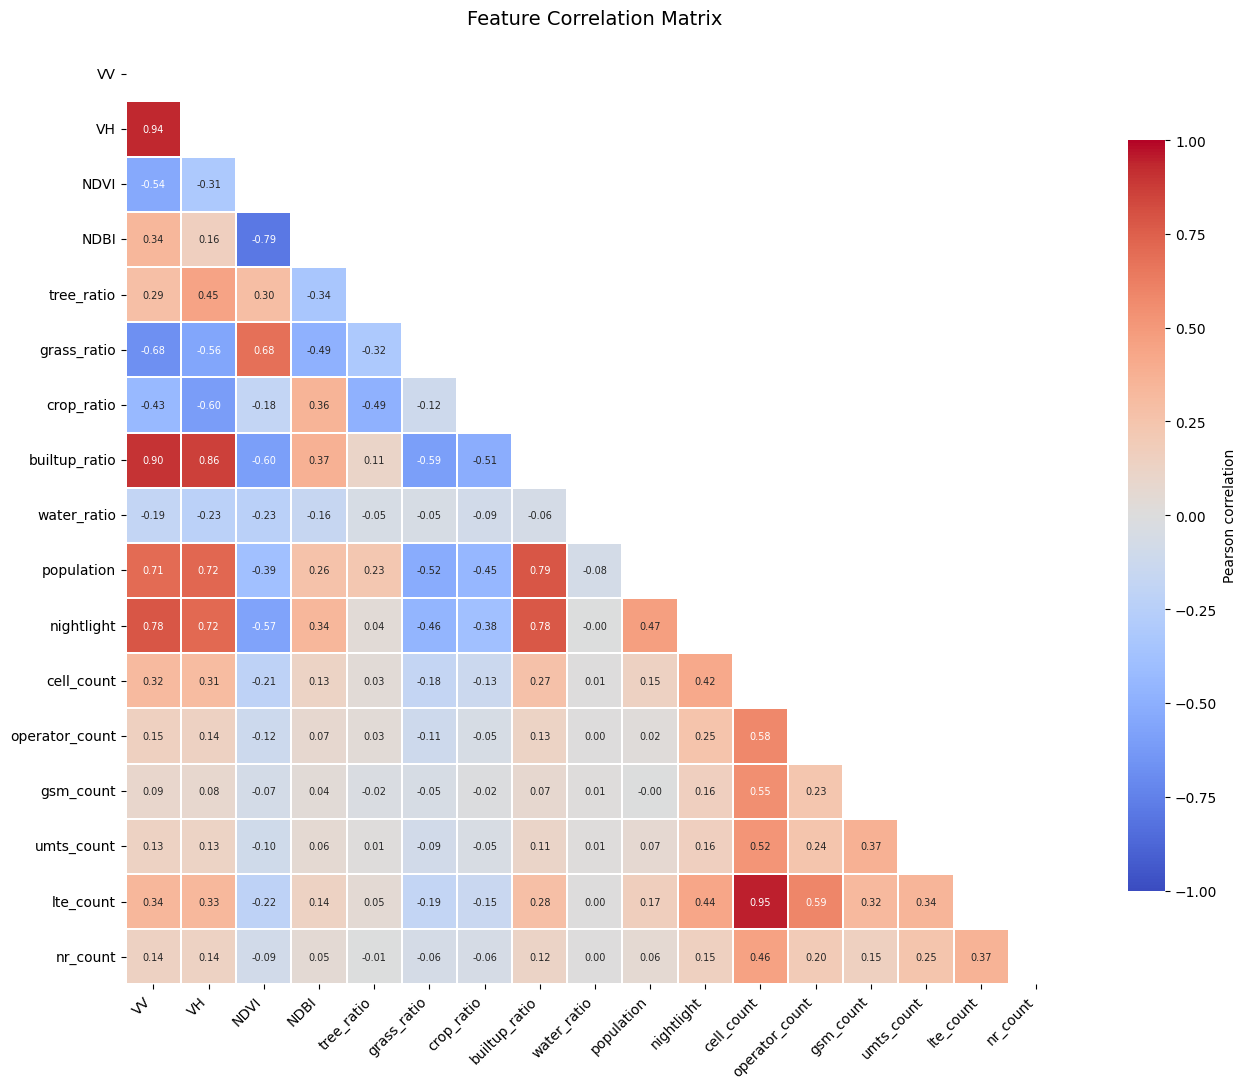

In [ ]:
# ============================================================
# EDA 9. Feature Correlation Matrix
# ============================================================

corr = dataset20[feature_cols].corr(method="pearson")

# Mask the upper triangle
mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    square=True,
    linewidths=0.3,
    cbar_kws={
        "label": "Pearson correlation",
        "shrink": 0.8
    }
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=14,
    pad=16
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Urbanisation and Cellular-Infrastructure Patterns

Joint patterns are examined between urbanisation indicators and technology-specific OpenCellID record counts.

Population, built-up land-cover ratio, and night-time light are divided into groups and compared with LTE and 5G NR infrastructure-count groups. Median RSRP and the number of contributing grids are reported for each combination.

※ Related dissertation sections
 - Section 4.1.2 (Exploratory Data Analysis)
 - Figure 4.3 (Median RSRP across Built-Up and OpenCellID Count Groups)
 - Table 4.1 (Summary of EDA Findings and Feature-Engineering Responses).

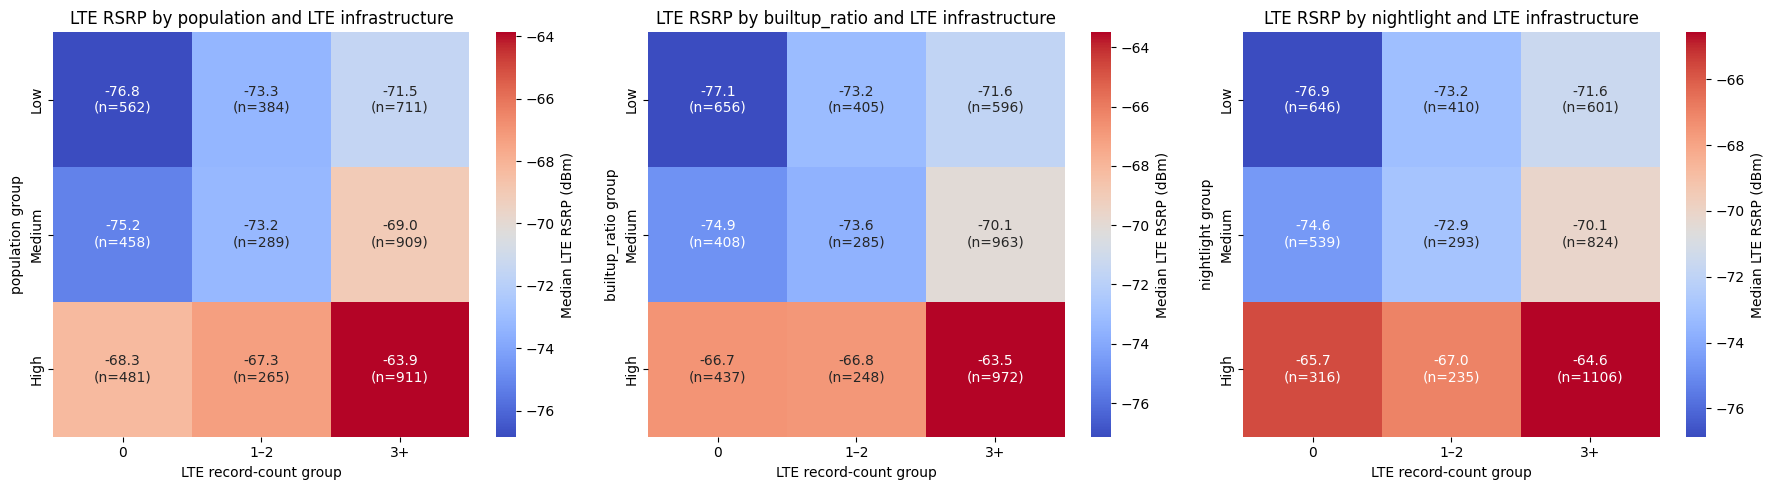

In [ ]:
# ============================================================
# EDA 10. Urbanisation × LTE Infrastructure Patterns
# ============================================================

urban_features = [
    "population",
    "builtup_ratio",
    "nightlight"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

interaction_tables = {}

for ax, feature in zip(axes, urban_features):

    temp = lte_data[
        [feature, "lte_count", "lte_median_rsrp"]
    ].dropna().copy()

    # Divide urbanisation feature into tertiles
    temp[f"{feature}_group"] = pd.qcut(
        temp[feature],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    # Group LTE infrastructure counts
    temp["lte_count_group"] = pd.cut(
        temp["lte_count"],
        bins=[-1, 0, 2, np.inf],
        labels=["0", "1–2", "3+"]
    )

    # Median RSRP
    median_table = temp.pivot_table(
        values="lte_median_rsrp",
        index=f"{feature}_group",
        columns="lte_count_group",
        aggfunc="median",
        observed=False
    )

    # Number of grids
    count_table = temp.pivot_table(
        values="lte_median_rsrp",
        index=f"{feature}_group",
        columns="lte_count_group",
        aggfunc="count",
        observed=False
    )

    # Annotation containing median and sample size
    annotations = median_table.copy().astype(object)

    for row in median_table.index:
        for column in median_table.columns:
            median_value = median_table.loc[row, column]
            count_value = count_table.loc[row, column]

            annotations.loc[row, column] = (
                f"{median_value:.1f}\n(n={count_value:.0f})"
                if pd.notna(median_value)
                else "NA"
            )

    interaction_tables[feature] = {
        "median": median_table,
        "count": count_table
    }

    sns.heatmap(
        median_table,
        annot=annotations,
        fmt="",
        cmap="coolwarm",
        ax=ax,
        cbar_kws={"label": "Median LTE RSRP (dBm)"}
    )

    ax.set_title(
        f"LTE RSRP by {feature} and LTE infrastructure"
    )
    ax.set_xlabel("LTE record-count group")
    ax.set_ylabel(f"{feature} group")

plt.tight_layout()
plt.show()

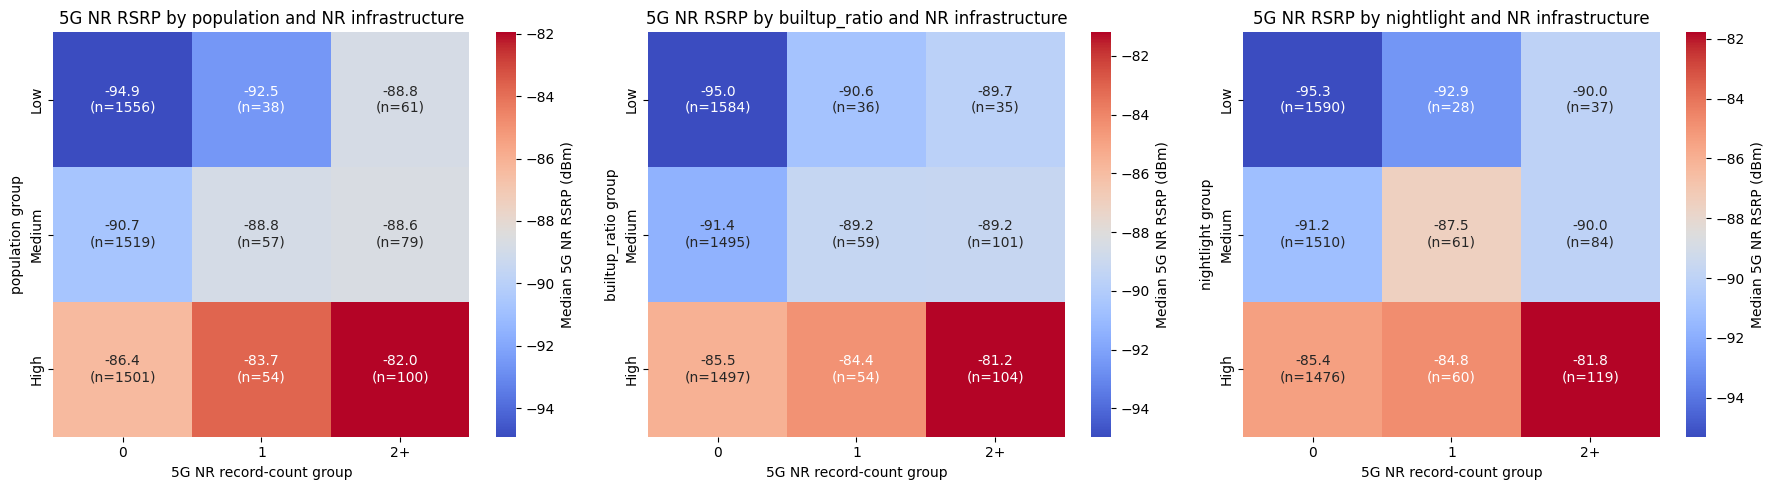

In [ ]:
# ============================================================
# EDA 11. Urbanisation × 5G NR Infrastructure Patterns
# ============================================================

urban_features = [
    "population",
    "builtup_ratio",
    "nightlight"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

nr_interaction_tables = {}

for ax, feature in zip(axes, urban_features):

    temp = nr_data[
        [feature, "nr_count", "nr_median_rsrp"]
    ].dropna().copy()

    # Divide urbanisation feature into tertiles
    temp[f"{feature}_group"] = pd.qcut(
        temp[feature],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    # NR records are highly zero-inflated
    temp["nr_count_group"] = pd.cut(
        temp["nr_count"],
        bins=[-1, 0, 1, np.inf],
        labels=["0", "1", "2+"]
    )

    # Median 5G NR RSRP
    median_table = temp.pivot_table(
        values="nr_median_rsrp",
        index=f"{feature}_group",
        columns="nr_count_group",
        aggfunc="median",
        observed=False
    )

    # Number of grids
    count_table = temp.pivot_table(
        values="nr_median_rsrp",
        index=f"{feature}_group",
        columns="nr_count_group",
        aggfunc="count",
        observed=False
    )

    # Combine median and sample size in annotations
    annotations = median_table.copy().astype(object)

    for row in median_table.index:
        for column in median_table.columns:
            median_value = median_table.loc[row, column]
            count_value = count_table.loc[row, column]

            annotations.loc[row, column] = (
                f"{median_value:.1f}\n(n={count_value:.0f})"
                if pd.notna(median_value)
                else "NA"
            )

    nr_interaction_tables[feature] = {
        "median": median_table,
        "count": count_table
    }

    sns.heatmap(
        median_table,
        annot=annotations,
        fmt="",
        cmap="coolwarm",
        ax=ax,
        cbar_kws={"label": "Median 5G NR RSRP (dBm)"}
    )

    ax.set_title(
        f"5G NR RSRP by {feature} and NR infrastructure"
    )
    ax.set_xlabel("5G NR record-count group")
    ax.set_ylabel(f"{feature} group")

plt.tight_layout()
plt.show()

## 6. Combined Remote-Sensing Patterns

Combined relationships between the remote-sensing predictors and LTE median RSRP are explored using grouped comparisons.

The analysis considers:

- NDVI and Sentinel-1 VV;
- built-up ratio and Sentinel-1 VH; and
- the difference between NDVI and NDBI.

These exploratory patterns help motivate the interaction features introduced during subsequent feature engineering.

※ Related dissertation sections
 - Section 2.6 (Public Geospatial Data as Predictors)
 - Section 4.1.2 (Exploratory Data Analysis)
 - Section 4.1.3 (Progressive Feature Engineering).

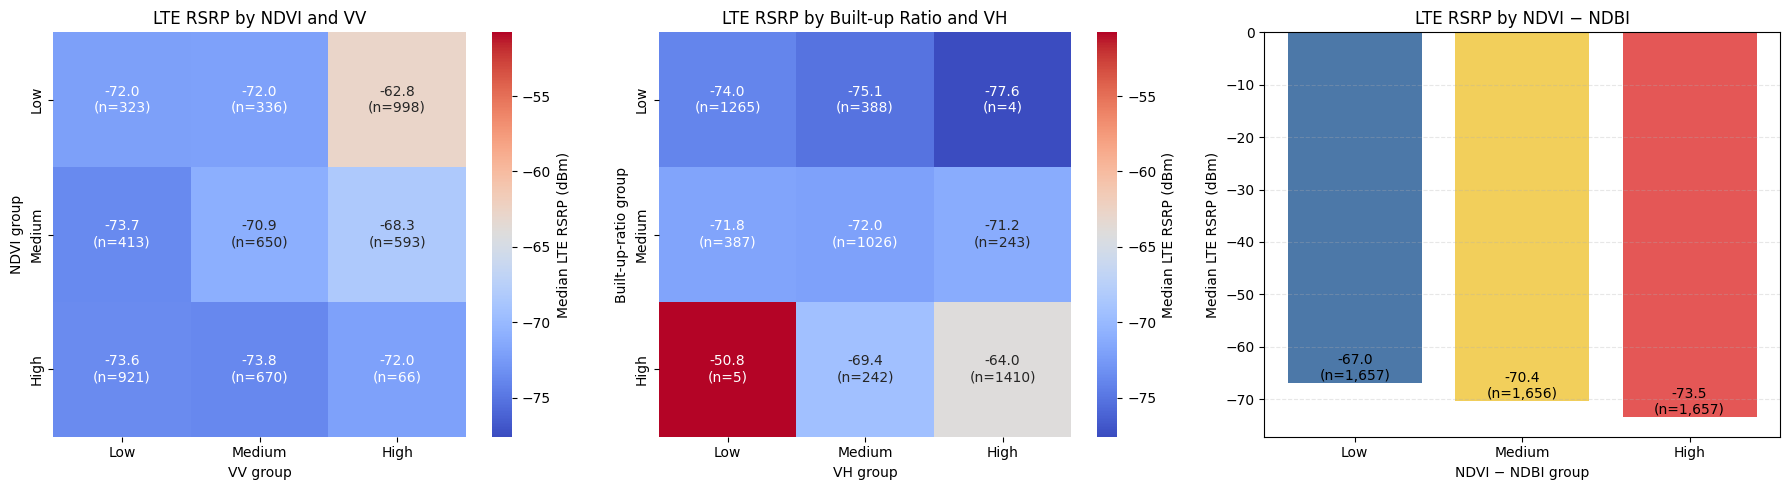

In [ ]:
# ============================================================
# EDA 12. Remote-Sensing Combined Patterns
# ============================================================

# ------------------------------------------------------------
# 1. NDVI × VV
# ------------------------------------------------------------

temp1 = lte_data[
    ["VV", "NDVI", "lte_median_rsrp"]
].dropna().copy()

temp1["VV_group"] = pd.qcut(
    temp1["VV"],
    q=3,
    labels=["Low", "Medium", "High"]
)

temp1["NDVI_group"] = pd.qcut(
    temp1["NDVI"],
    q=3,
    labels=["Low", "Medium", "High"]
)

table1 = temp1.pivot_table(
    values="lte_median_rsrp",
    index="NDVI_group",
    columns="VV_group",
    aggfunc="median",
    observed=False
)

count1 = temp1.pivot_table(
    values="lte_median_rsrp",
    index="NDVI_group",
    columns="VV_group",
    aggfunc="count",
    observed=False
)

# ------------------------------------------------------------
# 2. Built-up ratio × VH
# ------------------------------------------------------------

temp2 = lte_data[
    ["VH", "builtup_ratio", "lte_median_rsrp"]
].dropna().copy()

temp2["VH_group"] = pd.qcut(
    temp2["VH"],
    q=3,
    labels=["Low", "Medium", "High"]
)

temp2["builtup_group"] = pd.qcut(
    temp2["builtup_ratio"],
    q=3,
    labels=["Low", "Medium", "High"]
)

table2 = temp2.pivot_table(
    values="lte_median_rsrp",
    index="builtup_group",
    columns="VH_group",
    aggfunc="median",
    observed=False
)

count2 = temp2.pivot_table(
    values="lte_median_rsrp",
    index="builtup_group",
    columns="VH_group",
    aggfunc="count",
    observed=False
)

# Create annotations containing median and sample size
def create_annotations(values, counts):

    annotations = values.copy().astype(object)

    for row in values.index:
        for column in values.columns:
            annotations.loc[row, column] = (
                f"{values.loc[row, column]:.1f}\n"
                f"(n={counts.loc[row, column]:.0f})"
            )

    return annotations


annotations1 = create_annotations(table1, count1)
annotations2 = create_annotations(table2, count2)

# ------------------------------------------------------------
# 3. NDVI − NDBI
# ------------------------------------------------------------

temp3 = lte_data[
    ["NDVI", "NDBI", "lte_median_rsrp"]
].dropna().copy()

temp3["ndvi_minus_ndbi"] = (
    temp3["NDVI"] - temp3["NDBI"]
)

temp3["ndvi_ndbi_group"] = pd.qcut(
    temp3["ndvi_minus_ndbi"],
    q=3,
    labels=["Low", "Medium", "High"]
)

table3 = (
    temp3
    .groupby("ndvi_ndbi_group", observed=False)
    ["lte_median_rsrp"]
    .agg(["median", "count"])
)

# ------------------------------------------------------------
# 4. Visualisation
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Use the same colour scale for both heatmaps
vmin = min(table1.min().min(), table2.min().min())
vmax = max(table1.max().max(), table2.max().max())

sns.heatmap(
    table1,
    annot=annotations1,
    fmt="",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    cbar_kws={"label": "Median LTE RSRP (dBm)"}
)

axes[0].set_title("LTE RSRP by NDVI and VV")
axes[0].set_xlabel("VV group")
axes[0].set_ylabel("NDVI group")

sns.heatmap(
    table2,
    annot=annotations2,
    fmt="",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    cbar_kws={"label": "Median LTE RSRP (dBm)"}
)

axes[1].set_title("LTE RSRP by Built-up Ratio and VH")
axes[1].set_xlabel("VH group")
axes[1].set_ylabel("Built-up-ratio group")

bars = axes[2].bar(
    table3.index.astype(str),
    table3["median"],
    color=["#4C78A8", "#F2CF5B", "#E45756"]
)

for bar, median, count in zip(
    bars,
    table3["median"],
    table3["count"]
):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        median,
        f"{median:.1f}\n(n={count:,})",
        ha="center",
        va="bottom"
    )

axes[2].set_title("LTE RSRP by NDVI − NDBI")
axes[2].set_xlabel("NDVI − NDBI group")
axes[2].set_ylabel("Median LTE RSRP (dBm)")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Spatial Distribution of Signal Strength

The spatial distributions of median LTE and 5G NR RSRP are mapped across the labelled grid cells in England.

These maps are used to inspect broad geographic variation and determine whether signal strength exhibits spatial patterns that may not be fully represented by the existing environmental and infrastructure predictors.

※ Related dissertation sections
 - Section 4.1.2 (Exploratory Data Analysis)
 - Figure 4.4 (Spatial Distribution of LTE and 5G Median RSRP across England).

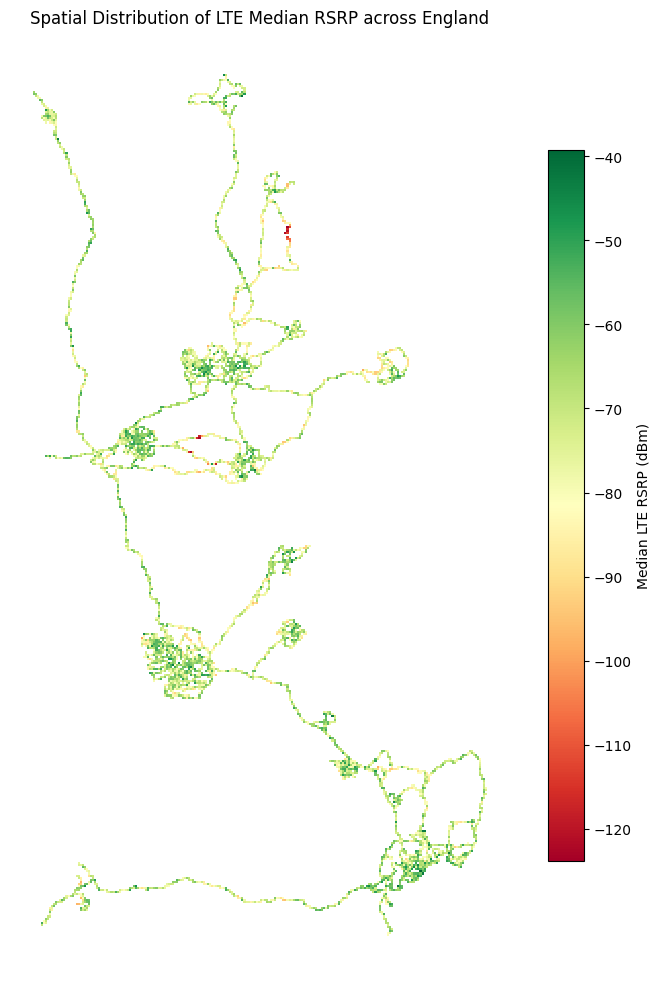

In [ ]:
# ============================================================
# EDA 13. Spatial Distribution of LTE Median RSRP
# ============================================================

import geopandas as gpd

# Load spatial Dataset20
dataset20_spatial = gpd.read_file(
    os.path.join(
        base_dir,
        "08_Final_Datasets",
        "dataset20_final.gpkg"
    ),
    layer="dataset20_final"
)

# Select LTE-labelled grids
spatial_lte = dataset20_spatial.dropna(
    subset=["lte_median_rsrp"]
).copy()

# Plot LTE median RSRP
ax = spatial_lte.plot(
    column="lte_median_rsrp",
    cmap="RdYlGn",
    legend=True,
    figsize=(8, 10),
    legend_kwds={
        "label": "Median LTE RSRP (dBm)",
        "shrink": 0.75
    }
)

ax.set_title(
    "Spatial Distribution of LTE Median RSRP across England"
)

ax.axis("off")
plt.tight_layout()
plt.show()

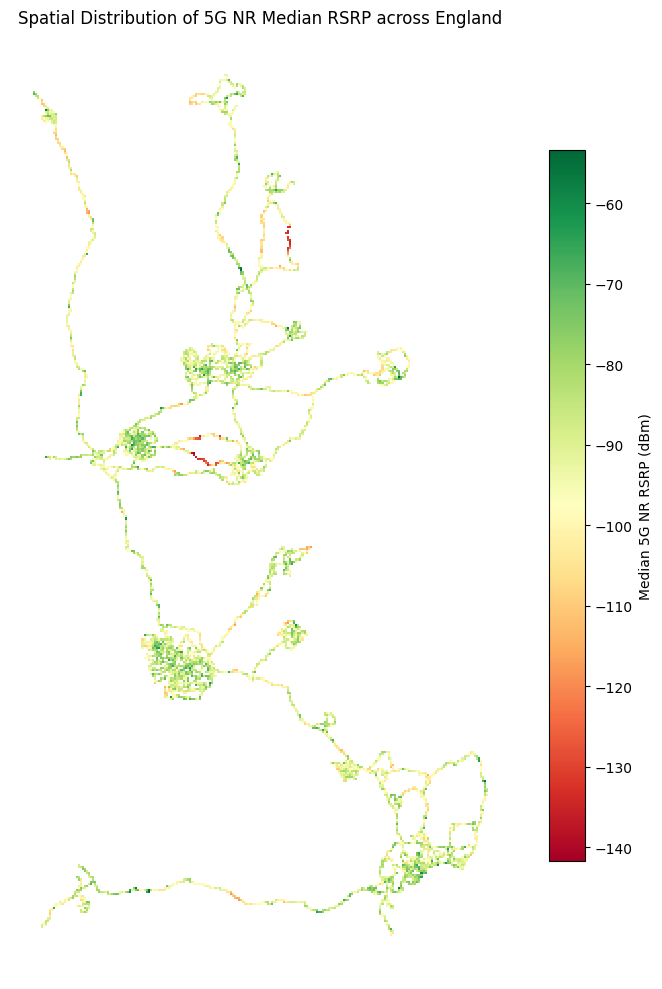

In [ ]:
# ============================================================
# EDA 14. Spatial Distribution of 5G NR Median RSRP
# ============================================================

# Select 5G NR-labelled grids
spatial_nr = dataset20_spatial.dropna(
    subset=["nr_median_rsrp"]
).copy()

# Plot 5G NR median RSRP
ax = spatial_nr.plot(
    column="nr_median_rsrp",
    cmap="RdYlGn",
    legend=True,
    figsize=(8, 10),
    legend_kwds={
        "label": "Median 5G NR RSRP (dBm)",
        "shrink": 0.75
    }
)

ax.set_title(
    "Spatial Distribution of 5G NR Median RSRP across England"
)

ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Geographic Gradient Analysis

The centroid of each grid cell is used to derive longitude, latitude, and straight-line distance from central London.

Grid cells are divided into five distance groups, and median LTE and 5G NR RSRP values are compared across these groups. This analysis examines whether broad geographic context may provide additional predictive information.

※ Related dissertation sections
 - Section 4.1.2 (Exploratory Data Analysis)
 - Section 4.1.3 (Progressive Feature Engineering)
 - Table 4.1 (Summary of EDA Findings and Feature-Engineering Responses).

In [ ]:
# ============================================================
# EDA 15. Prepare Geographic Variables
# ============================================================

from shapely.geometry import Point

# Use spatial Dataset20
geo_data = dataset20_spatial.copy()

# Calculate grid centroids in British National Grid
centroids_bng = geo_data.geometry.centroid

# Convert centroids to longitude and latitude
centroids_wgs84 = centroids_bng.to_crs(epsg=4326)

geo_data["longitude"] = centroids_wgs84.x.values
geo_data["latitude"] = centroids_wgs84.y.values

# Create London point and convert it to British National Grid
london_point = gpd.GeoSeries(
    [Point(-0.1278, 51.5074)],
    crs="EPSG:4326"
).to_crs(epsg=27700).iloc[0]

# Calculate straight-line distance to London
geo_data["distance_to_london_km"] = (
    centroids_bng.distance(london_point) / 1000
)

display(
    geo_data[
        ["longitude", "latitude", "distance_to_london_km"]
    ].describe()
)

,longitude,latitude,distance_to_london_km
count,4985.000000,4985.000000,4985.000000
mean,-1.444906,52.998756,198.094034
std,0.774273,1.007973,107.999186
min,-3.056898,51.297862,9.660103
25%,-1.994058,52.065439,132.440182
50%,-1.523877,52.997427,212.070569
75%,-0.903027,53.779056,272.649561
max,0.231333,55.082296,435.493590


,median_distance_km,lte_median_rsrp,nr_median_rsrp,lte_grid_count,nr_grid_count
distance_group,,,,,
Nearest,30.08,-68.72,-89.44,992,992
Near,152.60,-70.76,-89.87,995,996
Medium,212.07,-71.27,-89.83,993,992
Far,266.63,-68.80,-88.48,996,994
Farthest,335.48,-72.80,-93.53,994,991


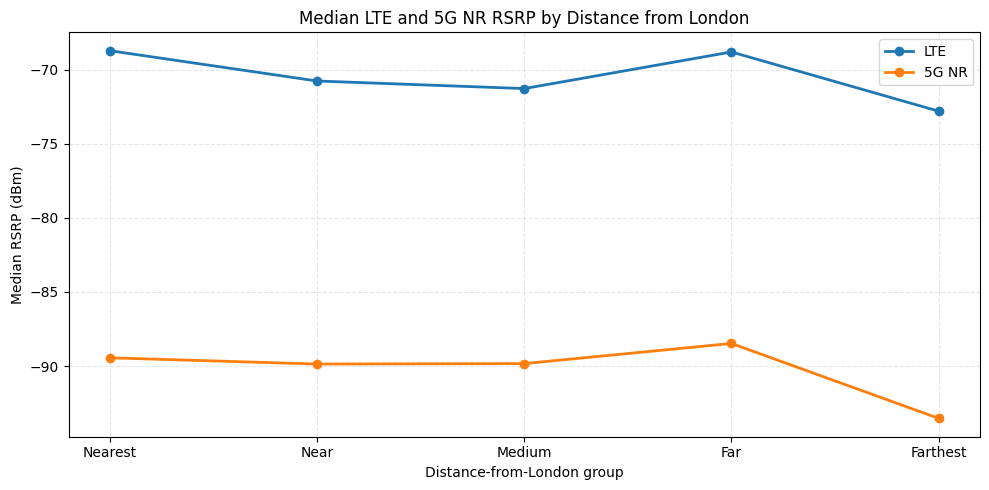

In [ ]:
# ============================================================
# EDA 16. Geographic Gradient in Signal Strength
# ============================================================

distance_order = [
    "Nearest",
    "Near",
    "Medium",
    "Far",
    "Farthest"
]

geo_data["distance_group"] = pd.qcut(
    geo_data["distance_to_london_km"],
    q=5,
    labels=distance_order
)

# Summarise distance and signal strength
geo_summary = (
    geo_data
    .groupby("distance_group", observed=False)
    .agg(
        median_distance_km=(
            "distance_to_london_km",
            "median"
        ),
        lte_median_rsrp=(
            "lte_median_rsrp",
            "median"
        ),
        nr_median_rsrp=(
            "nr_median_rsrp",
            "median"
        ),
        lte_grid_count=(
            "lte_median_rsrp",
            "count"
        ),
        nr_grid_count=(
            "nr_median_rsrp",
            "count"
        )
    )
    .reindex(distance_order)
)

display(geo_summary.round(2))

# Plot geographic gradients
plt.figure(figsize=(10, 5))

plt.plot(
    geo_summary.index,
    geo_summary["lte_median_rsrp"],
    marker="o",
    linewidth=2,
    label="LTE"
)

plt.plot(
    geo_summary.index,
    geo_summary["nr_median_rsrp"],
    marker="o",
    linewidth=2,
    label="5G NR"
)

plt.title(
    "Median LTE and 5G NR RSRP by Distance from London"
)
plt.xlabel("Distance-from-London group")
plt.ylabel("Median RSRP (dBm)")
plt.grid(linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()